# **Trademarkia - AI&ML Engineer Task**
***Problem Statement***

> You are given the 20 Newsgroups dataset: a collection of ~20,000 news posts spanning 20 overlapping topic categories. Your task is to build a lightweight semantic search system with three core components:
Fuzzy clustering of the corpus using vector embeddings and a vector database
A semantic cache layer that avoids redundant computation on similar queries built from first principles, without Redis or any dedicated caching middleware
A FastAPI service that exposes the cache as a live API endpoint with proper state management






*Installing necessary libraries*

In [1]:
!pip install sentence-transformers faiss-cpu pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 85.0 MB/s eta 0:00:00


# **Part 1 - Embedding & Vector Database Setup**



#*Data Loading and Cleaning*

*Raw Data Upload to Google Colab and Extraction*

In [2]:
from google.colab import files
uploaded = files.upload()

Saving 20_newsgroups.tar.gz to 20_newsgroups.tar.gz


In [3]:
import tarfile

tar = tarfile.open("20_newsgroups.tar.gz", "r:gz")
tar.extractall()
tar.close()

print("Dataset extracted")

/tmp/ipykernel_1236/1705233039.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Dataset extracted


*Document Loading*

In [4]:
import os
import pandas as pd

dataset_path = "20_newsgroups"

documents = []
categories = []
filenames = []

for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):

        for file in os.listdir(category_path):

            file_path = os.path.join(category_path, file)

            with open(file_path, encoding="latin1") as f:

                text = f.read()

                documents.append(text)
                categories.append(category)
                filenames.append(file)

corpus_df = pd.DataFrame({
    "text": documents,
    "category": categories,
    "file": filenames
})

print("Documents loaded:", len(corpus_df))
corpus_df.head()

Documents loaded: 19997


,text,category,file
0,Newsgroups: comp.sys.mac.hardware\nPath: canta...,comp.sys.mac.hardware,52246
1,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,comp.sys.mac.hardware,52309
2,Newsgroups: comp.sys.mac.hardware\nPath: canta...,comp.sys.mac.hardware,50467
3,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,comp.sys.mac.hardware,51640
4,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,comp.sys.mac.hardware,50537


*Cleaning the Corpus*

In [6]:
import re

def clean_text(text):
    text = re.sub(r"From:.*\n", "", text)
    text = re.sub(r">.*\n", "", text)
    text = re.sub(r"http\S+", "", text)
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

corpus_df["clean_text"] = corpus_df["text"].apply(clean_text)

In [7]:
corpus_df = corpus_df[corpus_df["clean_text"].str.len() > 50]

print("Remaining docs:", len(corpus_df))

Remaining docs: 19997


*To remove the Metadata from the Newspaper dataset*

In [8]:
def remove_usenet_metadata(text):

    parts = text.split("\n\n", 1)

    if len(parts) > 1:
        return parts[1]

    return text

In [9]:
corpus_df["clean_text"] = corpus_df["text"].apply(remove_usenet_metadata)

corpus_df.head()

,text,category,file,clean_text
0,Newsgroups: comp.sys.mac.hardware\nPath: canta...,comp.sys.mac.hardware,52246,I need help identifying this board that I foun...
1,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,comp.sys.mac.hardware,52309,For sale:\n\nMac IIfx with the following confi...
2,Newsgroups: comp.sys.mac.hardware\nPath: canta...,comp.sys.mac.hardware,50467,"In article <1osu69INN11r@tamsun.tamu.edu>, mcl..."
3,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,comp.sys.mac.hardware,51640,\nI have a new 25 MHz Motorola 68040 that I am...
4,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,comp.sys.mac.hardware,50537,"In article <C52qM2.on@dartvax.dartmouth.edu>,\..."


#Tokenization

In [10]:
!pip install nltk

In [11]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [12]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def tokenize_text(text):

    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]

    return tokens

In [13]:
corpus_df["tokens"] = corpus_df["clean_text"].apply(tokenize_text)
print("Tokenization complete")
corpus_df.head()

Tokenization complete


,text,category,file,clean_text,tokens
0,Newsgroups: comp.sys.mac.hardware\nPath: canta...,comp.sys.mac.hardware,52246,I need help identifying this board that I foun...,"[need, help, identifying, board, found, stuffe..."
1,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,comp.sys.mac.hardware,52309,For sale:\n\nMac IIfx with the following confi...,"[sale, mac, iifx, following, config, ram, hard..."
2,Newsgroups: comp.sys.mac.hardware\nPath: canta...,comp.sys.mac.hardware,50467,"In article <1osu69INN11r@tamsun.tamu.edu>, mcl...","[article, mclean, robert, mclean, wrote, macpl..."
3,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,comp.sys.mac.hardware,51640,\nI have a new 25 MHz Motorola 68040 that I am...,"[new, mhz, motorola, willing, sell, get, good,..."
4,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,comp.sys.mac.hardware,50537,"In article <C52qM2.on@dartvax.dartmouth.edu>,\...","[article, geoffb, thumper, writes, nwcs, schiz..."


In [14]:
corpus_df["processed_text"] = corpus_df["tokens"].apply(lambda x: " ".join(x))

corpus_df.head()

,text,category,file,clean_text,tokens,processed_text
0,Newsgroups: comp.sys.mac.hardware\nPath: canta...,comp.sys.mac.hardware,52246,I need help identifying this board that I foun...,"[need, help, identifying, board, found, stuffe...",need help identifying board found stuffed away...
1,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,comp.sys.mac.hardware,52309,For sale:\n\nMac IIfx with the following confi...,"[sale, mac, iifx, following, config, ram, hard...",sale mac iifx following config ram hard drive ...
2,Newsgroups: comp.sys.mac.hardware\nPath: canta...,comp.sys.mac.hardware,50467,"In article <1osu69INN11r@tamsun.tamu.edu>, mcl...","[article, mclean, robert, mclean, wrote, macpl...",article mclean robert mclean wrote macplus pro...
3,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,comp.sys.mac.hardware,51640,\nI have a new 25 MHz Motorola 68040 that I am...,"[new, mhz, motorola, willing, sell, get, good,...",new mhz motorola willing sell get good enough ...
4,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,comp.sys.mac.hardware,50537,"In article <C52qM2.on@dartvax.dartmouth.edu>,\...","[article, geoffb, thumper, writes, nwcs, schiz...",article geoffb thumper writes nwcs schizophren...


*Clean Dataset Saving*

In [15]:
corpus_df.to_csv("clean_newsgroups_dataset.csv", index=False)
print("Clean dataset saved")

Clean dataset saved


#Vector Embedding ( Sentence Transformers )

In [16]:
from sentence_transformers import SentenceTransformer
import torch

In [17]:
texts = corpus_df["processed_text"].tolist()
print("Total documents:", len(texts))

Total documents: 19997


*Selection of Model*

In [18]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2",
    device="cuda"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [19]:
embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True
)

print("Embedding shape:", embeddings.shape)

Batches:   0%|          | 0/625 [00:00<?, ?it/s]

Embedding shape: (19997, 384)


# **Vector DataBase Chromadb Store**

In [5]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    

In [20]:
import numpy as np
import chromadb

In [21]:
np.save("document_embeddings.npy", embeddings)

print("Embeddings saved")

Embeddings saved


In [22]:
batch_size = 4000

In [24]:
import chromadb
persistent_client = chromadb.PersistentClient(path="./chroma_db")

persistent_collection = persistent_client.get_or_create_collection(
    name="news_collection"
)

In [25]:
documents = corpus_df["processed_text"].tolist()
categories = corpus_df["category"].tolist()

for i in range(0, len(documents), batch_size):

    batch_docs = documents[i:i+batch_size]
    batch_embeddings = embeddings[i:i+batch_size]
    batch_metadata = [{"category": c} for c in categories[i:i+batch_size]]
    batch_ids = [str(j) for j in range(i, i + len(batch_docs))]

    persistent_collection.add(
        documents=batch_docs,
        embeddings=batch_embeddings.tolist(),
        metadatas=batch_metadata,
        ids=batch_ids
    )

    print(f"Inserted batch {i} → {i + len(batch_docs)}")

Inserted batch 0 → 4000
Inserted batch 4000 → 8000
Inserted batch 8000 → 12000
Inserted batch 12000 → 16000
Inserted batch 16000 → 19997


In [26]:
print(persistent_collection.count())

19997


*Test*

In [53]:
query = "space shuttle launch nasa"

query_embedding = model.encode([query])

results = persistent_collection.query(
    query_embeddings=query_embedding.tolist(),
    n_results=5
)

results["documents"]

[['well better get shuttle launch vehicle elv far backlog political messages campaign season candidates president launched one right around getting launch perot used shuttle seeing launches nixon ever pat',
  'sorry asking question entirely based technical aspects space could find answer faqs currently uk makes seeing space shuttle launch little difficult however selected exchange student louisiana state uni august absolutely determined get see space shuttle launch sometime year america hear bit long mailing list someone tell get tickets get please thanks much patience anyone else wants know tell summarize save poor people pay links april cruellest month andrew wong mixing memory desire wasteland',
  'essay writing space shuttle need better propulsion system research found rather clumsy launch safety hazards sitting hydrogen bomb etc beefs current space shuttle program propulsion please send ideas thanks lot terry ford nepean ontario canada',
  'coordinating space shuttle program offic

In [28]:
!zip -r chroma_db.zip chroma_db

  adding: chroma_db/ (stored 0%)
  adding: chroma_db/chroma.sqlite3 (deflated 46%)
  adding: chroma_db/64b05225-d588-482a-9d3d-7da36b4c5c8f/ (stored 0%)
  adding: chroma_db/64b05225-d588-482a-9d3d-7da36b4c5c8f/link_lists.bin (deflated 75%)
  adding: chroma_db/64b05225-d588-482a-9d3d-7da36b4c5c8f/header.bin (deflated 56%)
  adding: chroma_db/64b05225-d588-482a-9d3d-7da36b4c5c8f/data_level0.bin (deflated 11%)
  adding: chroma_db/64b05225-d588-482a-9d3d-7da36b4c5c8f/index_metadata.pickle (deflated 62%)
  adding: chroma_db/64b05225-d588-482a-9d3d-7da36b4c5c8f/length.bin (deflated 70%)


In [29]:
from google.colab import files
files.download("chroma_db.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Part 2 : Fuzzy Clustering

In [30]:
!pip install umap-learn scikit-learn joblib

In [31]:
import numpy as np
import umap
import joblib

from sklearn.mixture import GaussianMixture

In [32]:
print("Embedding shape:", embeddings.shape)

Embedding shape: (19997, 384)


#UMAP Dimensionality Reduction

In [33]:
reducer = umap.UMAP(
    n_components=20,      # reduce 384 → 20 dimensions
    n_neighbors=50,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

reduced_embeddings = reducer.fit_transform(embeddings)

print("Reduced shape:", reduced_embeddings.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced shape: (19997, 20)


*Verification of Variance*

In [34]:
import numpy as np
print(np.var(reduced_embeddings, axis=0))

[0.6443776  5.7112627  3.0363324  0.6277728  0.63417536 0.05345617
 0.5417481  0.4632837  0.35117608 0.15461741 0.03546694 0.17911644
 0.09660883 1.0174656  0.11333044 0.01740254 0.08340798 0.0489639
 0.00674494 0.15871395]


#Train GMM Model ( Soft Clustering )

*Training Gaussian Mixture Model*

*Chosen no. of Clusters is 15*

In [35]:
num_clusters = 15

gmm = GaussianMixture(
    n_components=num_clusters,
    covariance_type="full",
    random_state=42
)

gmm.fit(reduced_embeddings)

print("GMM training completed")

GMM training completed


*Cluster Probability Distribution*

In [36]:
cluster_probs = gmm.predict_proba(reduced_embeddings)

print("Cluster probability matrix:", cluster_probs.shape)

Cluster probability matrix: (19997, 15)


*Storing the Distribution*

In [37]:
corpus_df["dominant_cluster"] = cluster_probs.argmax(axis=1)

corpus_df.head()

,text,category,file,clean_text,tokens,processed_text,dominant_cluster
0,Newsgroups: comp.sys.mac.hardware\nPath: canta...,comp.sys.mac.hardware,52246,I need help identifying this board that I foun...,"[need, help, identifying, board, found, stuffe...",need help identifying board found stuffed away...,14
1,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,comp.sys.mac.hardware,52309,For sale:\n\nMac IIfx with the following confi...,"[sale, mac, iifx, following, config, ram, hard...",sale mac iifx following config ram hard drive ...,14
2,Newsgroups: comp.sys.mac.hardware\nPath: canta...,comp.sys.mac.hardware,50467,"In article <1osu69INN11r@tamsun.tamu.edu>, mcl...","[article, mclean, robert, mclean, wrote, macpl...",article mclean robert mclean wrote macplus pro...,14
3,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,comp.sys.mac.hardware,51640,\nI have a new 25 MHz Motorola 68040 that I am...,"[new, mhz, motorola, willing, sell, get, good,...",new mhz motorola willing sell get good enough ...,14
4,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,comp.sys.mac.hardware,50537,"In article <C52qM2.on@dartvax.dartmouth.edu>,\...","[article, geoffb, thumper, writes, nwcs, schiz...",article geoffb thumper writes nwcs schizophren...,3


*#Verifications of Perfect distributed Clustering*

*#Cluster Size*

In [38]:
corpus_df["dominant_cluster"].value_counts()

,count
dominant_cluster,
14,3102
1,2656
5,2264
6,1939
10,1677
9,1357
11,1236
13,1010
8,982


In [39]:
reducer_vis = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    metric="cosine",
    random_state=42
)

vis_embeddings = reducer_vis.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


*Plotting*

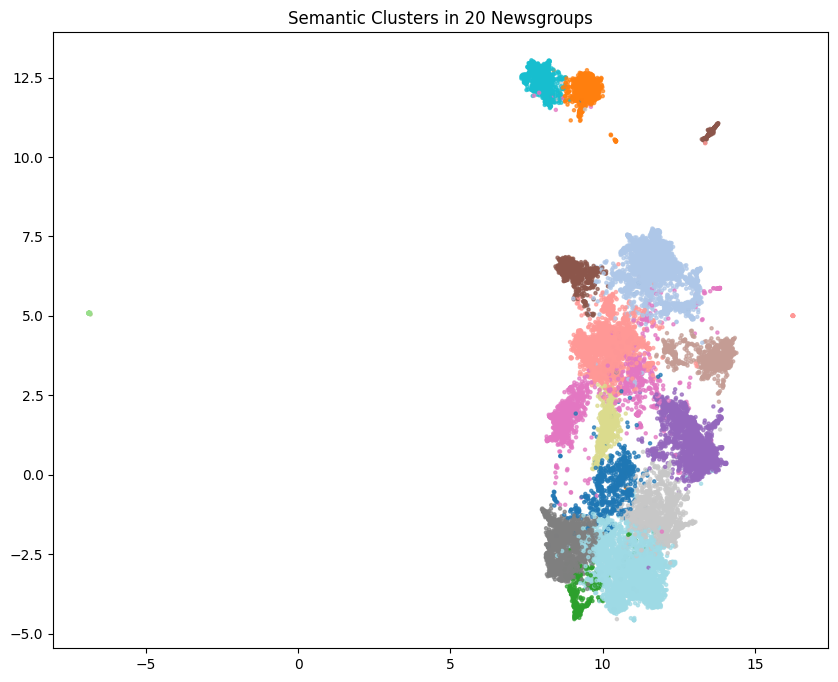

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.scatter(
    vis_embeddings[:,0],
    vis_embeddings[:,1],
    c=corpus_df["dominant_cluster"],
    s=5,
    cmap="tab20",
    alpha=0.7
)

plt.title("Semantic Clusters in 20 Newsgroups")
plt.show()



>The UMAP projection reveals several clearly separated clusters,indicating that the embedding model captures strong semantic
signals. At the same time, some clusters overlap in the central
region of the space, reflecting the semantic similarity between
related topics such as computer hardware and operating systems.

This structure supports the use of probabilistic clustering,
since some documents lie near cluster boundaries and may
belong to multiple semantic topics.




*#Justification for taking 15 as Number of Clusters*

In [42]:
cluster_range = [10, 15, 20]

for k in cluster_range:

    gmm = GaussianMixture(n_components=k, random_state=42)

    gmm.fit(reduced_embeddings)

    print("Clusters:", k, "BIC:", gmm.bic(reduced_embeddings))

Clusters: 10 BIC: -2164821.973938168
Clusters: 15 BIC: -2269132.6276720953
Clusters: 20 BIC: -2348866.4021100383


In [43]:
doc_id = 100

cluster_probs[doc_id]

array([3.44382340e-039, 0.00000000e+000, 0.00000000e+000, 2.49105173e-035,
       0.00000000e+000, 0.00000000e+000, 4.56726933e-302, 0.00000000e+000,
       0.00000000e+000, 1.45109794e-202, 1.75542896e-052, 3.58949621e-018,
       8.74078270e-271, 0.00000000e+000, 1.00000000e+000])

In [44]:
doc_id = 1625

probs = cluster_probs[doc_id]

for i, p in enumerate(probs):
    if p > 0.000:   # threshold
        print(f"cluster {i} → {p:.4f}")

cluster 5 → 0.0000
cluster 6 → 0.0000
cluster 8 → 1.0000
cluster 9 → 0.0000


In [45]:
cluster_id = 3

corpus_df[corpus_df["dominant_cluster"] == cluster_id]["processed_text"].head(5)

,processed_text
4,article geoffb thumper writes nwcs schizophren...
8,logitech hand scanner pc wondering anyone succ...
31,need extended keyboard like much space officia...
32,model one two laser printers apple introduced ...
38,hi terry could agree finally received datadesk...


In [46]:
import numpy as np

uncertainty = cluster_probs.max(axis=1)

boundary_docs = np.argsort(uncertainty)[:5]

In [47]:
doc_id = boundary_docs[0]

print(cluster_probs[doc_id])
print(corpus_df.iloc[doc_id]["processed_text"][:300])

[3.84298830e-001 0.00000000e+000 0.00000000e+000 5.22434855e-095
 0.00000000e+000 8.15491833e-144 9.73258481e-124 0.00000000e+000
 0.00000000e+000 5.92762964e-026 7.32671497e-087 3.64815646e-001
 7.99244082e-118 0.00000000e+000 2.50885524e-001]
anyone recomend good book article communications besides looked everywhere seems everyone tells nobody shows examples iccm examples asente swick give examples fact books looked discuss icc simply give condensed version iccm refer iccm find one example use atoms properties young book five hours bough


In [52]:
corpus_df["dominant_cluster"].value_counts()

,count
dominant_cluster,
11,2654
3,2606
4,2276
7,2041
5,2019
2,2000
14,1324
6,950
10,833


*#Save*

In [48]:
np.save("cluster_probabilities.npy", cluster_probs)

print("Cluster probabilities saved")

Cluster probabilities saved


In [49]:
corpus_df.to_csv("clustered_documents.csv", index=False)

print("Clustered dataset saved")

Clustered dataset saved


In [50]:
joblib.dump(reducer, "umap_model.pkl")
joblib.dump(gmm, "gmm_model.pkl")

print("Models saved")

Models saved


In [89]:
from google.colab import files

files.download("umap_model.pkl")
files.download("gmm_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Test Query

In [54]:
query = "existence of god religion beliefs christian bible discussion"

query_embedding = model.encode([query])

results = persistent_collection.query(
    query_embeddings=query_embedding.tolist(),
    n_results=1
)

results["documents"][0]
print(results["metadatas"][0])

[{'category': 'alt.atheism'}]
